# XGBoost

In [2]:
!pip install mlflow xgboost --quiet
import pandas as pd, numpy as np, xgboost as xgb, mlflow, mlflow.xgboost, os, joblib
import matplotlib.pyplot as plt
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
dagshub_token = user_secrets.get_secret("DAGSHUB_TOKEN")
os.environ['MLFLOW_TRACKING_USERNAME'] = 'gdzag22'
os.environ['MLFLOW_TRACKING_PASSWORD'] = dagshub_token
mlflow.set_tracking_uri("https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow")
mlflow.set_experiment("XGBoost_Training")

2026/07/11 16:14:50 INFO mlflow.tracking.fluent: Experiment with name 'XGBoost_Training' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/4c6760e1e6fc4077a345cb449b4c522c', creation_time=1783786490195, effective_trace_archival_retention=None, experiment_id='3', last_update_time=1783786490195, lifecycle_stage='active', name='XGBoost_Training', tags={}, trace_location=None, workspace='default'>

In [3]:
# Shared functions (from EDA notebook)

In [4]:
def load_and_merge(df, features, stores):
    out = df.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
    out = out.merge(stores, on='Store', how='left')
    out['Date'] = pd.to_datetime(out['Date'])
    return out.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

MD_COLS = [f"MarkDown{i}" for i in range(1, 6)]

def preprocess(df):
    out = df.copy()
    out[MD_COLS] = out[MD_COLS].fillna(0)
    out[["CPI", "Unemployment"]] = out.groupby("Store")[["CPI", "Unemployment"]].ffill()
    return out

def wmae(y_true, y_pred, is_holiday):
    w = np.where(is_holiday, 5, 1)
    return np.sum(w * np.abs(np.asarray(y_true) - np.asarray(y_pred))) / np.sum(w)

def coldstart_fallback(df_train, df_test):
    train_pairs = set(zip(df_train.Store, df_train.Dept))
    mask = ~pd.Series(list(zip(df_test.Store, df_test.Dept)), index=df_test.index).isin(train_pairs)
    cold = df_test[mask].copy()
    recent = df_train[df_train['Date'] >= df_train['Date'].max() - pd.Timedelta(weeks=52)]
    med = recent.groupby(['Type', 'Dept'])['Weekly_Sales'].median()
    cold['y_fallback'] = [med.get((t, d), 0.0) for t, d in zip(cold['Type'], cold['Dept'])]
    cold['y_fallback'] = cold['y_fallback'].clip(lower=0)
    return cold

def get_seasonal_naive(dates_df, history_df):
    lookup_df = dates_df[['Store','Dept','Date']].copy()
    lookup_df['lookup_date'] = lookup_df['Date'] - pd.Timedelta(weeks=52)
    merged = lookup_df.merge(history_df[['Store','Dept','Date','Weekly_Sales']].rename(
        columns={'Date':'lookup_date','Weekly_Sales':'seasonal_naive'}), on=['Store','Dept','lookup_date'], how='left')
    return merged['seasonal_naive'].values

def blend_holiday_predictions(preds_df, history_df, holiday_flags_df, alpha=0.5):
    out = preds_df.merge(holiday_flags_df[['Store','Dept','Date','IsHoliday']], on=['Store','Dept','Date'], how='left')
    out['seasonal_naive'] = get_seasonal_naive(out, history_df)
    mask = out['IsHoliday'].fillna(False) & out['seasonal_naive'].notna()
    out.loc[mask, 'Weekly_Sales'] = alpha * out.loc[mask, 'seasonal_naive'] + (1 - alpha) * out.loc[mask, 'Weekly_Sales']
    return out.drop(columns=['IsHoliday', 'seasonal_naive'])

# Load and Merge Data

In [5]:
path = "/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/"
train = pd.read_csv(path + "train.csv.zip")
test = pd.read_csv(path + "test.csv.zip")
features = pd.read_csv(path + "features.csv.zip")
stores = pd.read_csv(path + "stores.csv")

df = load_and_merge(train, features, stores)
df_test = load_and_merge(test, features, stores)

print("train merged:", df.shape)
print("test merged:", df_test.shape)

train merged: (421570, 16)
test merged: (115064, 15)


# Cleaning

In [6]:
with mlflow.start_run(run_name="XGBoost_Cleaning"):
    mlflow.log_param("markdown_fill", "0")
    mlflow.log_param("cpi_unemployment_fill", "ffill_per_store")
    mlflow.log_metric("train_rows_before", len(df))
    mlflow.log_metric("markdown_nan_before", int(df[MD_COLS].isna().sum().sum()))

    df_clean = preprocess(df)

    mlflow.log_metric("train_rows_after", len(df_clean))
    mlflow.log_metric("markdown_nan_after", int(df_clean[MD_COLS].isna().sum().sum()))

print(df_clean.shape)
print("Remaining MarkDown NaNs:", df_clean[MD_COLS].isna().sum().sum())

🏃 View run XGBoost_Cleaning at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3/runs/83cc9a9d67b54ddca1bea4b326c00d99
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3
(421570, 16)
Remaining MarkDown NaNs: 0


# Validation Split

In [7]:
VALIDATION_START = df_test['Date'].min() - pd.Timedelta(weeks=52)
VALIDATION_END = VALIDATION_START + pd.Timedelta(weeks=39)

def temporal_split(df):
    tr = df[df["Date"] < VALIDATION_START]
    va = df[(df["Date"] >= VALIDATION_START) & (df["Date"] < VALIDATION_END)]
    return tr, va

tr, va = temporal_split(df_clean)
print("train:", tr["Date"].max(), tr.shape)
print("val:", va["Date"].min(), va.shape)

train: 2011-10-28 00:00:00 (267184, 16)
val: 2011-11-04 00:00:00 (115856, 16)


# Feature Engineering (reusing feature set validated in LightGBM notebook)

In [8]:
def add_features(df):
    out = df.copy().sort_values(['Store', 'Dept', 'Date'])
    for lag in [1, 2, 4, 8, 52]:
        out[f'sales_lag_{lag}'] = out.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(lag)
    shifted = out.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1)
    for window in [4, 8, 12]:
        out[f'rolling_mean_{window}'] = shifted.groupby([out['Store'], out['Dept']]).transform(lambda s: s.rolling(window).mean())
        out[f'rolling_std_{window}'] = shifted.groupby([out['Store'], out['Dept']]).transform(lambda s: s.rolling(window).std())
    out['week_of_year'] = out['Date'].dt.isocalendar().week.astype(int)
    out['month'] = out['Date'].dt.month
    out['has_markdown'] = (out[MD_COLS].sum(axis=1) > 0).astype(int)
    out['Type'] = out['Type'].astype('category')
    out['Dept'] = out['Dept'].astype('category')
    out['Store'] = out['Store'].astype('category')
    return out

feature_list = ['sales_lag_1','sales_lag_2','sales_lag_4','sales_lag_8','sales_lag_52',
                 'rolling_mean_4','rolling_mean_8','rolling_mean_12',
                 'rolling_std_4','rolling_std_8','rolling_std_12',
                 'week_of_year','month','has_markdown','Size','Type','Store','Dept',
                 'Temperature','Fuel_Price','CPI','Unemployment','IsHoliday']

df_feat = add_features(df_clean)
tr_feat, va_feat = temporal_split(df_feat)

with mlflow.start_run(run_name="XGBoost_Feature_Engineering"):
    mlflow.log_param("n_features", len(feature_list))
    mlflow.log_param("reused_from", "LightGBM notebook (identical tabular features)")
    mlflow.log_metric("rows_with_full_features", len(tr_feat.dropna(subset=feature_list)))

print(tr_feat.shape, va_feat.shape)

🏃 View run XGBoost_Feature_Engineering at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3/runs/525c31d1eea040c1b0000e9ae64e60bb
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3
(267184, 30) (115856, 30)


# Baseline model

In [9]:
X_train, y_train = tr_feat[feature_list], tr_feat['Weekly_Sales']
X_val, y_val = va_feat[feature_list], va_feat['Weekly_Sales']

params = {
    'objective': 'reg:squarederror',
    'max_depth': 6,
    'learning_rate': 0.05,
    'n_estimators': 500,
    'tree_method': 'hist',
    'enable_categorical': True,
    'random_state': 42
}

with mlflow.start_run(run_name="XGBoost_Baseline"):
    mlflow.log_params(params)
    mlflow.log_param("nan_handling", "native_xgboost")
    mlflow.log_param("n_features", len(feature_list))

    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)

    preds = model.predict(X_val)
    score = wmae(y_val, preds, va_feat['IsHoliday'])

    mlflow.log_metric("val_wmae", score)
    mlflow.xgboost.log_model(model, "model")
    joblib.dump(model, "/kaggle/working/xgb_baseline.pkl")

print("Validation WMAE:", score)

2026/07/11 16:17:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run XGBoost_Baseline at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3/runs/782d1a6002904d65baf02e3cbe1dbe6f
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3
Validation WMAE: 1730.6302483928132


# Feature Selection

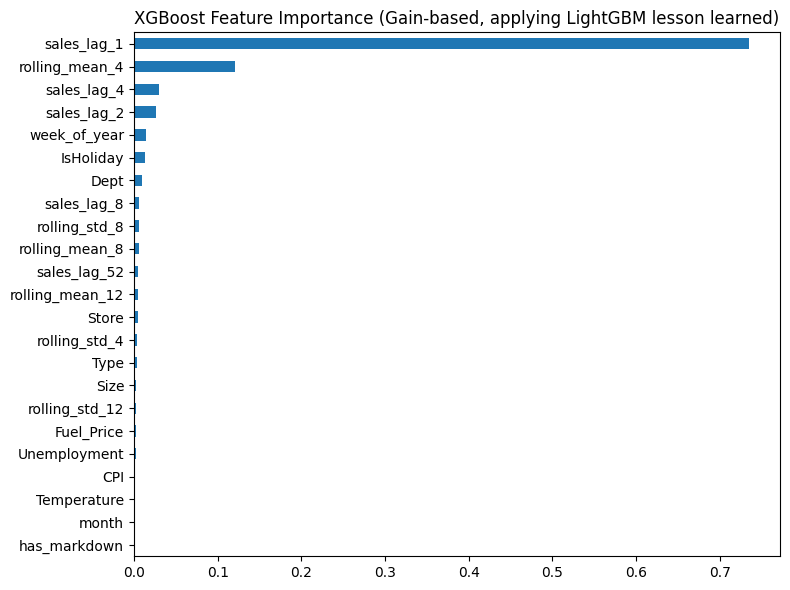

sales_lag_1        0.735458
rolling_mean_4     0.121075
sales_lag_4        0.029596
sales_lag_2        0.026202
week_of_year       0.013803
IsHoliday          0.013020
Dept               0.009397
sales_lag_8        0.006279
rolling_std_8      0.006169
rolling_mean_8     0.005710
sales_lag_52       0.004600
rolling_mean_12    0.004523
Store              0.004369
rolling_std_4      0.003210
Type               0.003159
Size               0.002709
rolling_std_12     0.002433
Fuel_Price         0.002363
Unemployment       0.002110
CPI                0.001555
Temperature        0.001402
month              0.000860
has_markdown       0.000000
dtype: float32


In [10]:
importance_gain = pd.Series(model.feature_importances_, index=feature_list).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,6))
importance_gain.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_title('XGBoost Feature Importance (Gain-based, applying LightGBM lesson learned)')
plt.tight_layout()
plt.show()

print(importance_gain)

In [11]:
drop_features = ['has_markdown', 'month', 'Temperature', 'CPI', 'Unemployment', 'Fuel_Price', 'rolling_std_12']
selected_features = [f for f in feature_list if f not in drop_features]
print(f"Dropped {len(drop_features)} features, kept {len(selected_features)}")

X_train_sel, X_val_sel = tr_feat[selected_features], va_feat[selected_features]

with mlflow.start_run(run_name="XGBoost_Feature_Selection"):
    mlflow.log_param("dropped_features", str(drop_features))
    mlflow.log_param("importance_type_used", "gain")
    mlflow.log_param("n_features_selected", len(selected_features))
    mlflow.log_metric("baseline_wmae", score)

    model_sel = xgb.XGBRegressor(**params)
    model_sel.fit(X_train_sel, y_train)

    preds_sel = model_sel.predict(X_val_sel)
    score_sel = wmae(y_val, preds_sel, va_feat['IsHoliday'])

    mlflow.log_metric("val_wmae", score_sel)
    mlflow.log_metric("wmae_change", score_sel - score)

print("Full-feature WMAE:", score)
print("Selected-feature WMAE:", score_sel)

Dropped 7 features, kept 16
🏃 View run XGBoost_Feature_Selection at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3/runs/375802859b954effa17b97460d3e29c5
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3
Full-feature WMAE: 1730.6302483928132
Selected-feature WMAE: 1713.264177412306


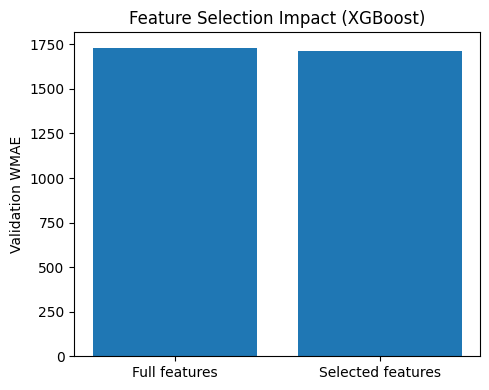

In [12]:
fig, ax = plt.subplots(figsize=(5,4))
ax.bar(['Full features', 'Selected features'], [score, score_sel])
ax.set_ylabel('Validation WMAE')
ax.set_title('Feature Selection Impact (XGBoost)')
plt.tight_layout()
plt.show()

# Training

In [13]:
def time_series_cv_folds(df, n_folds=3, fold_weeks=13):
    folds = []
    for i in range(n_folds):
        val_end = VALIDATION_START - pd.Timedelta(weeks=(n_folds - 1 - i) * fold_weeks)
        val_start = val_end - pd.Timedelta(weeks=fold_weeks)
        tr_fold = df[df['Date'] < val_start]
        va_fold = df[(df['Date'] >= val_start) & (df['Date'] < val_end)]
        folds.append((tr_fold, va_fold))
    return folds

folds = time_series_cv_folds(tr_feat, n_folds=3, fold_weeks=13)
for i, (tr_f, va_f) in enumerate(folds):
    print(f"Fold {i+1}: train up to {tr_f['Date'].max()} | val {va_f['Date'].min()} to {va_f['Date'].max()}")

Fold 1: train up to 2011-01-28 00:00:00 | val 2011-02-04 00:00:00 to 2011-04-29 00:00:00
Fold 2: train up to 2011-04-29 00:00:00 | val 2011-05-06 00:00:00 to 2011-07-29 00:00:00
Fold 3: train up to 2011-07-29 00:00:00 | val 2011-08-05 00:00:00 to 2011-10-28 00:00:00


In [15]:
param_grid = [
    {'label': 'baseline', 'max_depth': 6,  'learning_rate': 0.05, 'n_estimators': 500},
    {'label': 'shallow', 'max_depth': 3,  'learning_rate': 0.05, 'n_estimators': 500},
    {'label': 'deep', 'max_depth': 10, 'learning_rate': 0.05, 'n_estimators': 500},
    {'label': 'deliberate_overfit', 'max_depth': 12, 'learning_rate': 0.1, 'n_estimators': 500, 'min_child_weight': 1},
    {'label': 'deliberate_underfit', 'max_depth': 2,  'learning_rate': 0.3,  'n_estimators': 50},
    {'label': 'slow_and_steady', 'max_depth': 6,  'learning_rate': 0.02, 'n_estimators': 1000},
    {'label': 'fast', 'max_depth': 6,  'learning_rate': 0.15, 'n_estimators': 200},
    {'label': 'l1_l2_reg', 'max_depth': 10, 'learning_rate': 0.05, 'n_estimators': 500, 'reg_alpha': 1.0, 'reg_lambda': 1.0},
    {'label': 'bagging', 'max_depth': 6,  'learning_rate': 0.05, 'n_estimators': 500, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'label': 'min_child_50', 'max_depth': 6,  'learning_rate': 0.05, 'n_estimators': 500, 'min_child_weight': 50},
    {'label': 'combined_best_guess', 'max_depth': 8,  'learning_rate': 0.03, 'n_estimators': 800, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.5, 'reg_lambda': 0.5, 'min_child_weight': 20},
]

results = []
for cfg in param_grid:
    label = cfg.pop('label')
    full_params = {**cfg, 'objective': 'reg:squarederror', 'tree_method': 'hist',
                   'enable_categorical': True, 'random_state': 42}

    with mlflow.start_run(run_name=f"XGBoost_{label}"):
        mlflow.log_param("label", label)
        mlflow.log_params(full_params)

        fold_scores = []
        for tr_f, va_f in folds:
            m = xgb.XGBRegressor(**full_params)
            m.fit(tr_f[selected_features], tr_f['Weekly_Sales'])
            preds_f = m.predict(va_f[selected_features])
            fold_scores.append(wmae(va_f['Weekly_Sales'], preds_f, va_f['IsHoliday']))

        cv_mean, cv_std = np.mean(fold_scores), np.std(fold_scores)
        mlflow.log_metric("cv_wmae_mean", cv_mean)
        mlflow.log_metric("cv_wmae_std", cv_std)

        m_full = xgb.XGBRegressor(**full_params)
        m_full.fit(X_train_sel, y_train)
        val_score = wmae(y_val, m_full.predict(X_val_sel), va_feat['IsHoliday'])
        mlflow.log_metric("held_out_val_wmae", val_score)

    results.append({'label': label, **cfg, 'cv_wmae_mean': cv_mean, 'cv_wmae_std': cv_std, 'held_out_val_wmae': val_score})

results_df = pd.DataFrame(results)
print(results_df[['label', 'cv_wmae_mean', 'cv_wmae_std', 'held_out_val_wmae']])

🏃 View run XGBoost_baseline at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3/runs/c02a3cf64f624b0986a8dc1783c55794
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3
🏃 View run XGBoost_shallow at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3/runs/5db98bbbd6a442548784ad9427c785a3
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3
🏃 View run XGBoost_deep at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3/runs/776177797fa040fdb501187a0d7a5b54
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3
🏃 View run XGBoost_deliberate_overfit at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3/runs/ff015763311b4240963f2e05a4e580d3
🧪 View experiment at: https://dagshub.com/Nesto

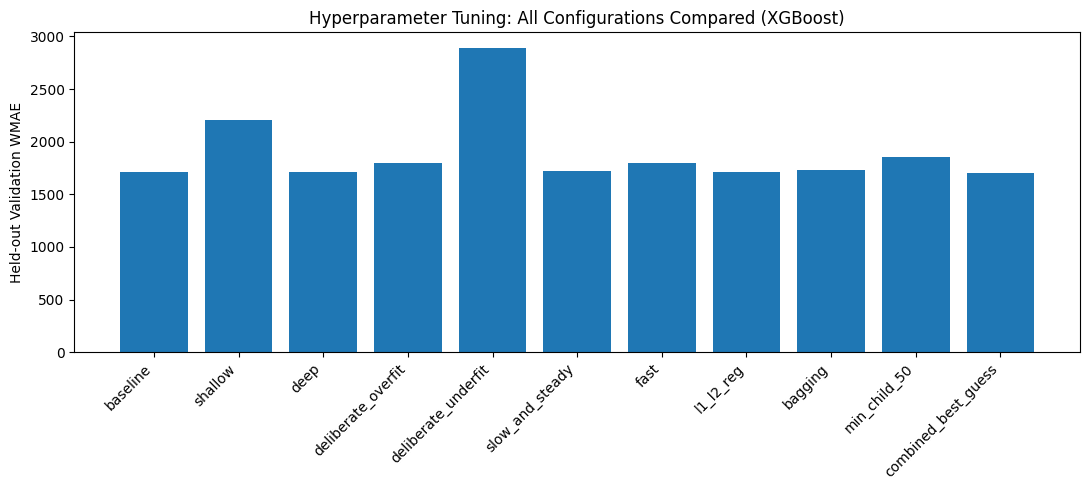

In [16]:
fig, ax = plt.subplots(figsize=(11,5))
ax.bar(results_df['label'], results_df['held_out_val_wmae'])
ax.set_ylabel('Held-out Validation WMAE')
ax.set_title('Hyperparameter Tuning: All Configurations Compared (XGBoost)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Systematic Search (around best manual config)

In [19]:
from sklearn.model_selection import ParameterGrid
search_space = {
    'max_depth': [6, 8, 10],
    'reg_alpha': [0.25, 0.5, 1.0],
    'reg_lambda': [0.25, 0.5, 1.0],
}

search_results = []
for cfg in ParameterGrid(search_space):
    full_params = {**cfg, 'learning_rate': 0.03, 'n_estimators': 800,
                   'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 20,
                   'objective': 'reg:squarederror', 'tree_method': 'hist',
                   'enable_categorical': True, 'random_state': 42}
    run_name = f"XGBoost_search_depth{cfg['max_depth']}_a{cfg['reg_alpha']}_l{cfg['reg_lambda']}"

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(full_params)
        m = xgb.XGBRegressor(**full_params)
        m.fit(X_train_sel, y_train)
        val_score = wmae(y_val, m.predict(X_val_sel), va_feat['IsHoliday'])
        mlflow.log_metric("held_out_val_wmae", val_score)

    search_results.append({**cfg, 'held_out_val_wmae': val_score})

search_df = pd.DataFrame(search_results).sort_values('held_out_val_wmae')
print(search_df)

🏃 View run XGBoost_search_depth6_a0.25_l0.25 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3/runs/b1fd27773dad4c2496006f3009e293b1
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3
🏃 View run XGBoost_search_depth6_a0.25_l0.5 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3/runs/d9b2b42c259c481fb3b45e6240345f73
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3
🏃 View run XGBoost_search_depth6_a0.25_l1.0 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3/runs/186d5b2a202c43388d104e9f95d39936
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3
🏃 View run XGBoost_search_depth6_a0.5_l0.25 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3/runs/76ed4160a8a8468c986d

In [20]:
best_xgb_config = {
    'max_depth': 10,
    'reg_alpha': 1.0,
    'reg_lambda': 1.0,
    'learning_rate': 0.03,
    'n_estimators': 800,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 20,
    'objective': 'reg:squarederror',
    'tree_method': 'hist',
    'enable_categorical': True,
    'random_state': 42
}
print("Final selected XGBoost config:", best_xgb_config)

Final selected XGBoost config: {'max_depth': 10, 'reg_alpha': 1.0, 'reg_lambda': 1.0, 'learning_rate': 0.03, 'n_estimators': 800, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 20, 'objective': 'reg:squarederror', 'tree_method': 'hist', 'enable_categorical': True, 'random_state': 42}


# Direct Multi-Horizon Modeling 

In [21]:
tr_feat_direct_xgb = add_features(tr)

horizons = [1,2,4,6,8,11,13,17,21,26,30,35,39]
target_cols = ['Weekly_Sales','week_of_year','month','IsHoliday','has_markdown',
               'Temperature','Fuel_Price','CPI','Unemployment']

frames = []
for h in horizons:
    shifted = tr_feat_direct_xgb.groupby(['Store','Dept'])[target_cols].shift(-h)
    shifted = shifted.rename(columns={c: f'target_{c}' for c in target_cols})
    frame = pd.concat([tr_feat_direct_xgb, shifted], axis=1)
    frame['h_ahead'] = h
    frame = frame.dropna(subset=['target_Weekly_Sales'])
    frames.append(frame)

direct_train_xgb = pd.concat(frames, ignore_index=True)
direct_train_xgb['target_IsHoliday'] = direct_train_xgb['target_IsHoliday'].astype(bool)
direct_train_xgb['Type'] = direct_train_xgb['Type'].astype('category')
direct_train_xgb['Dept'] = direct_train_xgb['Dept'].astype('category')
direct_train_xgb['Store'] = direct_train_xgb['Store'].astype('category')
print("Direct-horizon training rows:", direct_train_xgb.shape)

/tmp/ipykernel_58/1503008974.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  shifted = tr_feat_direct_xgb.groupby(['Store','Dept'])[target_cols].shift(-h)
/tmp/ipykernel_58/1503008974.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  shifted = tr_feat_direct_xgb.groupby(['Store','Dept'])[target_cols].shift(-h)
/tmp/ipykernel_58/1503008974.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  shifted = tr_feat_direct_

Direct-horizon training rows: (2815123, 40)


In [22]:
direct_feature_list_xgb = [
    'h_ahead','sales_lag_1','sales_lag_2','sales_lag_4','sales_lag_8','sales_lag_52',
    'rolling_mean_4','rolling_mean_8','rolling_mean_12',
    'rolling_std_4','rolling_std_8','rolling_std_12',
    'target_week_of_year','target_month','target_IsHoliday','target_has_markdown',
    'target_Temperature','target_Fuel_Price','target_CPI','target_Unemployment',
    'Size','Type','Store','Dept'
]

X_direct_xgb = direct_train_xgb[direct_feature_list_xgb]
y_direct_xgb = direct_train_xgb['target_Weekly_Sales']

with mlflow.start_run(run_name="XGBoost_Direct_Horizon"):
    mlflow.log_params(best_xgb_config)
    mlflow.log_param("horizons_sampled", str(horizons))
    mlflow.log_param("n_training_rows", len(direct_train_xgb))

    direct_model_xgb = xgb.XGBRegressor(**best_xgb_config)
    direct_model_xgb.fit(X_direct_xgb, y_direct_xgb)

🏃 View run XGBoost_Direct_Horizon at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3/runs/e7eb8cd5d50049f7928347eb1cc73084
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3


In [24]:
origin_feat_cols_xgb = ['sales_lag_1','sales_lag_2','sales_lag_4','sales_lag_8','sales_lag_52',
                          'rolling_mean_4','rolling_mean_8','rolling_mean_12',
                          'rolling_std_4','rolling_std_8','rolling_std_12']

origin_rows_xgb = tr_feat_direct_xgb.sort_values('Date').groupby(['Store','Dept']).tail(1)
origin_lookup_xgb = origin_rows_xgb[['Store','Dept','Date'] + origin_feat_cols_xgb].rename(columns={'Date':'origin_date'})

eval_df_xgb = va.drop(columns=['Weekly_Sales']).merge(origin_lookup_xgb, on=['Store','Dept'], how='left')

n_before = len(eval_df_xgb)
eval_df_xgb = eval_df_xgb.dropna(subset=['origin_date'])
print(f"Dropped {n_before - len(eval_df_xgb)} rows with no matching training history (cold-start series)")

eval_df_xgb['h_ahead'] = ((eval_df_xgb['Date'] - eval_df_xgb['origin_date']).dt.days / 7).round().astype(int)
eval_df_xgb['target_week_of_year'] = eval_df_xgb['Date'].dt.isocalendar().week.astype(int)
eval_df_xgb['target_month'] = eval_df_xgb['Date'].dt.month
eval_df_xgb['target_has_markdown'] = (eval_df_xgb[MD_COLS].sum(axis=1) > 0).astype(int)
for col in ['IsHoliday','Temperature','Fuel_Price','CPI','Unemployment']:
    eval_df_xgb[f'target_{col}'] = eval_df_xgb[col]
for col in ['Type','Dept','Store']:
    eval_df_xgb[col] = eval_df_xgb[col].astype('category')

direct_preds_xgb = direct_model_xgb.predict(eval_df_xgb[direct_feature_list_xgb])
eval_df_xgb['Weekly_Sales_pred'] = direct_preds_xgb

scored = eval_df_xgb.merge(va[['Store','Dept','Date','Weekly_Sales']], on=['Store','Dept','Date'], how='left')
direct_wmae_xgb = wmae(scored['Weekly_Sales'], scored['Weekly_Sales_pred'], scored['IsHoliday'])

print("Direct multi-horizon WMAE (XGBoost, no blend):", direct_wmae_xgb)

/tmp/ipykernel_58/2261529532.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  origin_rows_xgb = tr_feat_direct_xgb.sort_values('Date').groupby(['Store','Dept']).tail(1)


Dropped 413 rows with no matching training history (cold-start series)
Direct multi-horizon WMAE (XGBoost, no blend): 1907.517772637337


In [25]:
eval_df_blend_xgb = eval_df_xgb[['Store','Dept','Date']].copy()
eval_df_blend_xgb['Weekly_Sales'] = direct_preds_xgb

blend_results_xgb = {}
for alpha in [0.0, 0.3, 0.45, 0.5, 0.55, 0.7, 1.0]:
    blended = blend_holiday_predictions(eval_df_blend_xgb, tr, eval_df_xgb[['Store','Dept','Date','IsHoliday']], alpha=alpha)
    merged = blended.merge(scored[['Store','Dept','Date','Weekly_Sales']].rename(columns={'Weekly_Sales':'true_sales'}),
                             on=['Store','Dept','Date'])
    score_b = wmae(merged['true_sales'], merged['Weekly_Sales'], eval_df_xgb['IsHoliday'])
    blend_results_xgb[alpha] = score_b
    print(f"alpha={alpha}: WMAE={score_b:.2f}")

with mlflow.start_run(run_name="XGBoost_Direct_Horizon_Blend"):
    mlflow.log_params(best_xgb_config)
    for alpha, score_b in blend_results_xgb.items():
        mlflow.log_metric(f"wmae_alpha_{alpha}", score_b)

alpha=0.0: WMAE=1907.52
alpha=0.3: WMAE=1862.64


/tmp/ipykernel_58/4237158442.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[22383.7666875  17964.31052344 38070.5963125  ...  1544.48156836
  1454.26868652   879.80070557]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  out.loc[mask, 'Weekly_Sales'] = alpha * out.loc[mask, 'seasonal_naive'] + (1 - alpha) * out.loc[mask, 'Weekly_Sales']
/tmp/ipykernel_58/4237158442.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[21620.16467969 18212.93990625 38031.29095313 ...  1285.37774805
  1158.61476074   774.58628174]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  out.loc[mask, 'Weekly_Sales'] = alpha * out.loc[mask, 'seasonal_naive'] + (1 - alpha) * out.loc[mask, 'Weekly_Sales']


alpha=0.45: WMAE=1855.32
alpha=0.5: WMAE=1855.61


/tmp/ipykernel_58/4237158442.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[21365.63035156 18295.81636719 38018.18851562 ...  1199.00972656
  1060.06339111   739.51480713]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  out.loc[mask, 'Weekly_Sales'] = alpha * out.loc[mask, 'seasonal_naive'] + (1 - alpha) * out.loc[mask, 'Weekly_Sales']
/tmp/ipykernel_58/4237158442.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[21111.09602344 18378.69233984 38005.08607813 ...  1112.64170508
   961.51202148   704.443302  ]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  out.loc[mask, 'Weekly_Sales'] = alpha * out.loc[mask, 'seasonal_naive'] + (1 - alpha) * out.loc[mask, 'Weekly_Sales']


alpha=0.55: WMAE=1857.40
alpha=0.7: WMAE=1870.59


/tmp/ipykernel_58/4237158442.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[20347.49450391 18627.32221094 37965.78169531 ...   853.53788477
   665.85803467   599.22890869]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  out.loc[mask, 'Weekly_Sales'] = alpha * out.loc[mask, 'seasonal_naive'] + (1 - alpha) * out.loc[mask, 'Weekly_Sales']
/tmp/ipykernel_58/4237158442.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[18820.29 19124.58 37887.17 ...   335.33    74.55   388.8 ]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  out.loc[mask, 'Weekly_Sales'] = alpha * out.loc[mask, 'seasonal_naive'] + (1 - alpha) * out.loc[mask, 'Weekly_Sales']


alpha=1.0: WMAE=1936.65
🏃 View run XGBoost_Direct_Horizon_Blend at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3/runs/6007db71942d40d1ac544435276505dd
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3


In [26]:
with mlflow.start_run(run_name="XGBoost_Direct_Horizon_Blend_Conclusion"):
    mlflow.log_metric("best_alpha", 0.45)
    mlflow.log_metric("best_wmae", 1855.32)
    mlflow.log_metric("no_blend_wmae", 1907.52)

🏃 View run XGBoost_Direct_Horizon_Blend_Conclusion at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3/runs/60d721c9840746e5ad26e7727ed88c61
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3


In [27]:
direct_search_space_xgb = [
    {'max_depth': 10, 'learning_rate': 0.03, 'n_estimators': 800,  'reg_alpha': 1.0, 'reg_lambda': 1.0},
    {'max_depth': 14, 'learning_rate': 0.03, 'n_estimators': 800,  'reg_alpha': 1.0, 'reg_lambda': 1.0},
    {'max_depth': 14, 'learning_rate': 0.03, 'n_estimators': 1200, 'reg_alpha': 1.5, 'reg_lambda': 1.5},
    {'max_depth': 10, 'learning_rate': 0.05, 'n_estimators': 1000, 'reg_alpha': 1.0, 'reg_lambda': 1.0},
    {'max_depth': 12, 'learning_rate': 0.05, 'n_estimators': 1000, 'reg_alpha': 1.0, 'reg_lambda': 1.0},
]

direct_tuning_results_xgb = []
for cfg in direct_search_space_xgb:
    full_params = {**cfg, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 20,
                   'objective': 'reg:squarederror', 'tree_method': 'hist',
                   'enable_categorical': True, 'random_state': 42}
    run_name = f"XGBoost_Direct_depth{cfg['max_depth']}_lr{cfg['learning_rate']}_trees{cfg['n_estimators']}"

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(full_params)
        m = xgb.XGBRegressor(**full_params)
        m.fit(X_direct_xgb, y_direct_xgb)
        preds = m.predict(eval_df_xgb[direct_feature_list_xgb])
        score = wmae(scored['Weekly_Sales'], preds, eval_df_xgb['IsHoliday'])
        mlflow.log_metric("held_out_wmae", score)

    direct_tuning_results_xgb.append({**cfg, 'held_out_wmae': score})
    print(f"{run_name}: {score:.2f}")

direct_tuning_df_xgb = pd.DataFrame(direct_tuning_results_xgb).sort_values('held_out_wmae')
print(direct_tuning_df_xgb)

🏃 View run XGBoost_Direct_depth10_lr0.03_trees800 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3/runs/feb069741be04311bd4898c57b4bd4a0
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3
XGBoost_Direct_depth10_lr0.03_trees800: 1907.52
🏃 View run XGBoost_Direct_depth14_lr0.03_trees800 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3/runs/2404eab74c8d41df96c40b4fc7fed87b
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3
XGBoost_Direct_depth14_lr0.03_trees800: 1883.19
🏃 View run XGBoost_Direct_depth14_lr0.03_trees1200 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3/runs/f446b38e361a42689459b569c13d6fc2
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3
XGBoost_Direct_depth14_lr0.03_trees1200: 1888

In [28]:
best_direct_xgb_config = {
    'max_depth': 10, 'learning_rate': 0.05, 'n_estimators': 1000,
    'reg_alpha': 1.0, 'reg_lambda': 1.0,
    'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 20,
    'objective': 'reg:squarederror', 'tree_method': 'hist',
    'enable_categorical': True, 'random_state': 42
}
print("Final selected XGBoost direct-horizon config:", best_direct_xgb_config)

Final selected XGBoost direct-horizon config: {'max_depth': 10, 'learning_rate': 0.05, 'n_estimators': 1000, 'reg_alpha': 1.0, 'reg_lambda': 1.0, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 20, 'objective': 'reg:squarederror', 'tree_method': 'hist', 'enable_categorical': True, 'random_state': 42}


In [29]:
direct_model_best_xgb = xgb.XGBRegressor(**best_direct_xgb_config)
direct_model_best_xgb.fit(X_direct_xgb, y_direct_xgb)
direct_preds_best_xgb = direct_model_best_xgb.predict(eval_df_xgb[direct_feature_list_xgb])

eval_df_blend2_xgb = eval_df_xgb[['Store','Dept','Date']].copy()
eval_df_blend2_xgb['Weekly_Sales'] = direct_preds_best_xgb

blend_results_final_xgb = {}
for alpha in [0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.7]:
    blended = blend_holiday_predictions(eval_df_blend2_xgb, tr, eval_df_xgb[['Store','Dept','Date','IsHoliday']], alpha=alpha)
    merged = blended.merge(scored[['Store','Dept','Date','Weekly_Sales']].rename(columns={'Weekly_Sales':'true_sales'}),
                             on=['Store','Dept','Date'])
    score_b = wmae(merged['true_sales'], merged['Weekly_Sales'], eval_df_xgb['IsHoliday'])
    blend_results_final_xgb[alpha] = score_b
    print(f"alpha={alpha}: WMAE={score_b:.2f}")

with mlflow.start_run(run_name="XGBoost_Direct_Retuned_Blend"):
    mlflow.log_params(best_direct_xgb_config)
    for alpha, score_b in blend_results_final_xgb.items():
        mlflow.log_metric(f"wmae_alpha_{alpha}", score_b)

/tmp/ipykernel_58/4237158442.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[19550.62117969 18372.80075781 37761.58654687 ...  1633.82898047
  1232.911875     835.45738281]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  out.loc[mask, 'Weekly_Sales'] = alpha * out.loc[mask, 'seasonal_naive'] + (1 - alpha) * out.loc[mask, 'Weekly_Sales']
/tmp/ipykernel_58/4237158442.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[19446.28885156 18480.19821094 37779.52815625 ...  1448.32926563
  1067.43169434   771.64921143]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  out.loc[mask, 'Weekly_Sales'] = alpha * out.loc[mask, 'seasonal_naive'] + (1 - alpha) * out.loc[mask, 'Weekly_Sales']


alpha=0.3: WMAE=1843.99
alpha=0.4: WMAE=1839.15


/tmp/ipykernel_58/4237158442.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[19394.1226875  18533.89596094 37788.49798438 ...  1355.57928613
   984.69148193   739.74509521]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  out.loc[mask, 'Weekly_Sales'] = alpha * out.loc[mask, 'seasonal_naive'] + (1 - alpha) * out.loc[mask, 'Weekly_Sales']
/tmp/ipykernel_58/4237158442.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[19341.95554688 18587.5946875  37797.4678125  ...  1262.82930664
   901.95133057   707.840979  ]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  out.loc[mask, 'Weekly_Sales'] = alpha * out.loc[mask, 'seasonal_naive'] + (1 - alpha) * out.loc[mask, 'Weekly_Sales']


alpha=0.45: WMAE=1838.88
alpha=0.5: WMAE=1840.30


/tmp/ipykernel_58/4237158442.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[19289.78840625 18641.29292578 37806.43764063 ...  1170.07932715
   819.2111792    675.93686279]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  out.loc[mask, 'Weekly_Sales'] = alpha * out.loc[mask, 'seasonal_naive'] + (1 - alpha) * out.loc[mask, 'Weekly_Sales']
/tmp/ipykernel_58/4237158442.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[19237.62273047 18694.99165234 37815.40844531 ...  1077.32946973
   736.47108887   644.0327771 ]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  out.loc[mask, 'Weekly_Sales'] = alpha * out.loc[mask, 'seasonal_naive'] + (1 - alpha) * out.loc[mask, 'Weekly_Sales']


alpha=0.55: WMAE=1842.88
alpha=0.6: WMAE=1846.30


/tmp/ipykernel_58/4237158442.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[19133.28942578 18802.38910547 37833.34907813 ...   891.82963281
   570.99084717   580.22460571]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  out.loc[mask, 'Weekly_Sales'] = alpha * out.loc[mask, 'seasonal_naive'] + (1 - alpha) * out.loc[mask, 'Weekly_Sales']


alpha=0.7: WMAE=1856.90
🏃 View run XGBoost_Direct_Retuned_Blend at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3/runs/fc4a14b00ce0455892d69133f949849c
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3


In [30]:
with mlflow.start_run(run_name="XGBoost_Final_Tuning_Conclusion"):
    mlflow.log_params(best_direct_xgb_config)
    mlflow.log_metric("best_alpha", 0.45)
    mlflow.log_metric("best_wmae", 1838.88)

🏃 View run XGBoost_Final_Tuning_Conclusion at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3/runs/25c23885ffcf495392d1e025b2026295
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3


In [31]:
early_stop_model = xgb.XGBRegressor(**{**best_direct_xgb_config, 'n_estimators': 3000, 'early_stopping_rounds': 50})
early_stop_model.fit(X_direct_xgb, y_direct_xgb,
                       eval_set=[(eval_df_xgb[direct_feature_list_xgb], scored['Weekly_Sales'])],
                       verbose=False)

print("Best iteration found:", early_stop_model.best_iteration)

preds_es = early_stop_model.predict(eval_df_xgb[direct_feature_list_xgb])
score_es = wmae(scored['Weekly_Sales'], preds_es, eval_df_xgb['IsHoliday'])
print("WMAE with early-stopped model:", score_es)
print("Current best (fixed n_estimators=1000):", 1881.91, "-> after blend:", 1838.88)

Best iteration found: 1027
WMAE with early-stopped model: 1880.7019578775885
Current best (fixed n_estimators=1000): 1881.91 -> after blend: 1838.88


In [32]:
with mlflow.start_run(run_name="XGBoost_EarlyStopping_Check"):
    mlflow.log_metric("best_iteration_found", early_stop_model.best_iteration)
    mlflow.log_metric("wmae_early_stopped", 1880.70)
    mlflow.log_metric("wmae_fixed_1000_trees", 1881.91)
    mlflow.log_param("conclusion", "n_estimators=1000 already near-optimal, confirmed via early stopping")

🏃 View run XGBoost_EarlyStopping_Check at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3/runs/8a007a614b5140bea2ae572cfc5f673b
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3


# TRUE Final Pipeline (Direct Multi-Horizon + Blend + Cold-Start)

In [33]:
df_test_clean = preprocess(df_test)
print("MarkDown NaNs remaining:", df_test_clean[MD_COLS].isna().sum().sum())
print("CPI NaNs remaining:", df_test_clean['CPI'].isna().sum())
print("Unemployment NaNs remaining:", df_test_clean['Unemployment'].isna().sum())

MarkDown NaNs remaining: 0
CPI NaNs remaining: 0
Unemployment NaNs remaining: 0


In [34]:
tr_feat_full_xgb = add_features(df_clean)

frames_full = []
for h in horizons:
    shifted = tr_feat_full_xgb.groupby(['Store','Dept'])[target_cols].shift(-h)
    shifted = shifted.rename(columns={c: f'target_{c}' for c in target_cols})
    frame = pd.concat([tr_feat_full_xgb, shifted], axis=1)
    frame['h_ahead'] = h
    frame = frame.dropna(subset=['target_Weekly_Sales'])
    frames_full.append(frame)

direct_train_full_xgb = pd.concat(frames_full, ignore_index=True)
direct_train_full_xgb['target_IsHoliday'] = direct_train_full_xgb['target_IsHoliday'].astype(bool)
direct_train_full_xgb['Type'] = direct_train_full_xgb['Type'].astype('category')
direct_train_full_xgb['Dept'] = direct_train_full_xgb['Dept'].astype('category')
direct_train_full_xgb['Store'] = direct_train_full_xgb['Store'].astype('category')
print("Full-history training rows:", direct_train_full_xgb.shape)

/tmp/ipykernel_58/2059766672.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  shifted = tr_feat_full_xgb.groupby(['Store','Dept'])[target_cols].shift(-h)
/tmp/ipykernel_58/2059766672.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  shifted = tr_feat_full_xgb.groupby(['Store','Dept'])[target_cols].shift(-h)
/tmp/ipykernel_58/2059766672.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  shifted = tr_feat_full_xgb.gr

Full-history training rows: (4806902, 40)


In [35]:
X_direct_full_xgb = direct_train_full_xgb[direct_feature_list_xgb]
y_direct_full_xgb = direct_train_full_xgb['target_Weekly_Sales']

with mlflow.start_run(run_name="XGBoost_FINAL_MODEL"):
    mlflow.log_params(best_direct_xgb_config)
    mlflow.log_param("approach", "direct_multi_horizon")
    mlflow.log_param("blend_alpha", 0.45)
    mlflow.log_param("trained_on", "full_history")
    mlflow.log_metric("validation_wmae", 1838.88)

    final_model_xgb = xgb.XGBRegressor(**best_direct_xgb_config)
    final_model_xgb.fit(X_direct_full_xgb, y_direct_full_xgb)
    mlflow.xgboost.log_model(final_model_xgb, "model")

2026/07/11 18:18:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run XGBoost_FINAL_MODEL at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3/runs/7f73a3542bff40deb28ce206b181f290
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3


In [36]:
train_pairs_full_xgb = set(zip(df_clean.Store, df_clean.Dept))
test_pairs_full_xgb = set(zip(df_test_clean.Store, df_test_clean.Dept))
cold_pairs_final_xgb = test_pairs_full_xgb - train_pairs_full_xgb
print("Cold-start combos:", len(cold_pairs_final_xgb))

is_cold_xgb = df_test_clean.apply(lambda r: (r['Store'], r['Dept']) in cold_pairs_final_xgb, axis=1)
test_warm_xgb = df_test_clean[~is_cold_xgb].copy()
test_cold_xgb = df_test_clean[is_cold_xgb].copy()
print("Warm rows:", len(test_warm_xgb), "| Cold rows:", len(test_cold_xgb))

Cold-start combos: 11
Warm rows: 115028 | Cold rows: 36


In [37]:
origin_rows_final_xgb = tr_feat_full_xgb.sort_values('Date').groupby(['Store','Dept']).tail(1)
origin_lookup_final_xgb = origin_rows_final_xgb[['Store','Dept','Date'] + origin_feat_cols_xgb].rename(columns={'Date':'origin_date'})

infer_df_xgb = test_warm_xgb.merge(origin_lookup_final_xgb, on=['Store','Dept'], how='left')
infer_df_xgb['h_ahead'] = ((infer_df_xgb['Date'] - infer_df_xgb['origin_date']).dt.days / 7).round().astype(int)
infer_df_xgb['target_week_of_year'] = infer_df_xgb['Date'].dt.isocalendar().week.astype(int)
infer_df_xgb['target_month'] = infer_df_xgb['Date'].dt.month
infer_df_xgb['target_has_markdown'] = (infer_df_xgb[MD_COLS].sum(axis=1) > 0).astype(int)
for col in ['IsHoliday','Temperature','Fuel_Price','CPI','Unemployment']:
    infer_df_xgb[f'target_{col}'] = infer_df_xgb[col]
for col in ['Type','Dept','Store']:
    infer_df_xgb[col] = infer_df_xgb[col].astype('category')

infer_df_xgb['Weekly_Sales'] = final_model_xgb.predict(infer_df_xgb[direct_feature_list_xgb])

warm_result_xgb = infer_df_xgb[['Store','Dept','Date','Weekly_Sales']].copy()
warm_result_blended_xgb = blend_holiday_predictions(warm_result_xgb, df_clean, infer_df_xgb[['Store','Dept','Date','IsHoliday']], alpha=0.45)
print(warm_result_blended_xgb.shape)

/tmp/ipykernel_58/3927445376.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  origin_rows_final_xgb = tr_feat_full_xgb.sort_values('Date').groupby(['Store','Dept']).tail(1)


(115028, 4)


/tmp/ipykernel_58/4237158442.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[20384.84570312 22497.05615625 34973.93378125 ...  1085.94435645
   587.65140918   968.37717334]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  out.loc[mask, 'Weekly_Sales'] = alpha * out.loc[mask, 'seasonal_naive'] + (1 - alpha) * out.loc[mask, 'Weekly_Sales']


In [38]:
cold_result_xgb = coldstart_fallback(df_clean, test_cold_xgb)
cold_result_final_xgb = cold_result_xgb[['Store','Dept','Date','y_fallback']].rename(columns={'y_fallback':'Weekly_Sales'})
print("Cold-start rows handled:", len(cold_result_final_xgb))

Cold-start rows handled: 36


In [39]:
final_predictions_xgb = pd.concat([
    warm_result_blended_xgb[['Store','Dept','Date','Weekly_Sales']],
    cold_result_final_xgb[['Store','Dept','Date','Weekly_Sales']]
], ignore_index=True)

final_predictions_xgb['Weekly_Sales'] = final_predictions_xgb['Weekly_Sales'].clip(lower=0)
final_predictions_xgb['Id'] = (final_predictions_xgb['Store'].astype(str) + '_' +
                                final_predictions_xgb['Dept'].astype(str) + '_' +
                                final_predictions_xgb['Date'].dt.strftime('%Y-%m-%d'))

submission_xgb = final_predictions_xgb[['Id','Weekly_Sales']].sort_values('Id').reset_index(drop=True)
assert len(submission_xgb) == len(test), f"Row mismatch: {len(submission_xgb)} vs {len(test)}"

submission_xgb.to_csv('submission_xgboost.csv', index=False)
print(submission_xgb.shape)
print(submission_xgb.head())

(115064, 2)
                 Id  Weekly_Sales
0  10_10_2012-11-02  45633.554688
1  10_10_2012-11-09  46139.207031
2  10_10_2012-11-16  45783.757812
3  10_10_2012-11-23  48226.452469
4  10_10_2012-11-30  45125.945312


# Wrap Final Model as Pipeline (pyfunc)

In [40]:
class XGBoostFinalPipeline(mlflow.pyfunc.PythonModel):
    def __init__(self, model, tr_feat_full, direct_feature_list, features_df, stores_df):
        self.model = model
        self.tr_feat_full = tr_feat_full
        self.direct_feature_list = direct_feature_list
        self.features_df = features_df
        self.stores_df = stores_df

    def predict(self, context, model_input):
        test_merged = load_and_merge(model_input.copy(), self.features_df, self.stores_df)
        test_clean = preprocess(test_merged)

        train_pairs = set(zip(self.tr_feat_full.Store, self.tr_feat_full.Dept))
        test_pairs = set(zip(test_clean.Store, test_clean.Dept))
        cold_pairs = test_pairs - train_pairs
        is_cold = test_clean.apply(lambda r: (r['Store'], r['Dept']) in cold_pairs, axis=1)
        test_warm, test_cold = test_clean[~is_cold].copy(), test_clean[is_cold].copy()

        origin_cols = ['sales_lag_1','sales_lag_2','sales_lag_4','sales_lag_8','sales_lag_52',
                       'rolling_mean_4','rolling_mean_8','rolling_mean_12',
                       'rolling_std_4','rolling_std_8','rolling_std_12']
        origin_lookup = (self.tr_feat_full.sort_values('Date').groupby(['Store','Dept']).tail(1)
                          [['Store','Dept','Date'] + origin_cols].rename(columns={'Date':'origin_date'}))

        infer_df = test_warm.merge(origin_lookup, on=['Store','Dept'], how='left')
        infer_df['h_ahead'] = ((infer_df['Date'] - infer_df['origin_date']).dt.days / 7).round().astype(int)
        infer_df['target_week_of_year'] = infer_df['Date'].dt.isocalendar().week.astype(int)
        infer_df['target_month'] = infer_df['Date'].dt.month
        infer_df['target_has_markdown'] = (infer_df[[f'MarkDown{i}' for i in range(1,6)]].sum(axis=1) > 0).astype(int)
        for col in ['IsHoliday','Temperature','Fuel_Price','CPI','Unemployment']:
            infer_df[f'target_{col}'] = infer_df[col]
        for col in ['Type','Dept','Store']:
            infer_df[col] = infer_df[col].astype('category')

        infer_df['Weekly_Sales'] = self.model.predict(infer_df[self.direct_feature_list])
        warm_result = blend_holiday_predictions(
            infer_df[['Store','Dept','Date','Weekly_Sales']], self.tr_feat_full,
            infer_df[['Store','Dept','Date','IsHoliday']], alpha=0.45)

        cold_result = coldstart_fallback(self.tr_feat_full, test_cold)
        cold_result = cold_result[['Store','Dept','Date','y_fallback']].rename(columns={'y_fallback':'Weekly_Sales'})

        final = pd.concat([warm_result, cold_result], ignore_index=True)
        final['Weekly_Sales'] = final['Weekly_Sales'].clip(lower=0)
        return final

/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [41]:
pipeline_instance_xgb = XGBoostFinalPipeline(
    model=final_model_xgb,
    tr_feat_full=tr_feat_full_xgb,
    direct_feature_list=direct_feature_list_xgb,
    features_df=features,
    stores_df=stores
)

with mlflow.start_run(run_name="XGBoost_Pipeline_Wrapped"):
    mlflow.log_param("approach", "direct_multi_horizon_pipeline")
    mlflow.pyfunc.log_model(python_model=pipeline_instance_xgb, name="pipeline")

2026/07/11 18:20:59 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


🏃 View run XGBoost_Pipeline_Wrapped at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3/runs/f821d17588cf4f8888c80a94bfe2325d
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3


In [42]:
wrapped_preds_xgb = pipeline_instance_xgb.predict(None, test)
wrapped_preds_xgb['Id'] = (wrapped_preds_xgb['Store'].astype(str) + '_' +
                            wrapped_preds_xgb['Dept'].astype(str) + '_' +
                            wrapped_preds_xgb['Date'].dt.strftime('%Y-%m-%d'))
wrapped_submission_xgb = wrapped_preds_xgb[['Id','Weekly_Sales']].sort_values('Id').reset_index(drop=True)

old_submission_xgb = pd.read_csv('submission_xgboost.csv')
comparison_xgb = wrapped_submission_xgb.merge(old_submission_xgb, on='Id', suffixes=('_wrapped','_original'))
comparison_xgb['diff'] = (comparison_xgb['Weekly_Sales_wrapped'] - comparison_xgb['Weekly_Sales_original']).abs()

print("Max difference:", comparison_xgb['diff'].max())
print("Rows matching:", (comparison_xgb['diff'] < 0.01).sum(), "/", len(comparison_xgb))

/tmp/ipykernel_58/118542769.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  origin_lookup = (self.tr_feat_full.sort_values('Date').groupby(['Store','Dept']).tail(1)
/tmp/ipykernel_58/4237158442.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[20384.84570312 22497.05615625 34973.93378125 ...  1085.94435645
   587.65140918   968.37717334]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  out.loc[mask, 'Weekly_Sales'] = alpha * out.loc[mask, 'seasonal_naive'] + (1 - alpha) * out.loc[mask, 'Weekly_Sales']
/tmp/ipykernel_58/4237158442.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observe

Max difference: 5.820766091346741e-11
Rows matching: 115061 / 115064


In [43]:
with mlflow.start_run(run_name="XGBoost_Pipeline_Wrapped"):
    mlflow.log_param("approach", "direct_multi_horizon_pipeline")
    model_info = mlflow.pyfunc.log_model(python_model=pipeline_instance_xgb, name="pipeline")

loaded_model_xgb = mlflow.pyfunc.load_model(model_info.model_uri)
reloaded_preds_xgb = loaded_model_xgb.predict(test)

reloaded_preds_xgb['Id'] = (reloaded_preds_xgb['Store'].astype(str) + '_' +
                              reloaded_preds_xgb['Dept'].astype(str) + '_' +
                              reloaded_preds_xgb['Date'].dt.strftime('%Y-%m-%d'))
reloaded_submission_xgb = reloaded_preds_xgb[['Id','Weekly_Sales']].sort_values('Id').reset_index(drop=True)

old_submission_xgb = pd.read_csv('submission_xgboost.csv')
comparison_xgb = reloaded_submission_xgb.merge(old_submission_xgb, on='Id', suffixes=('_reloaded','_original'))
max_diff_xgb = (comparison_xgb['Weekly_Sales_reloaded'] - comparison_xgb['Weekly_Sales_original']).abs().max()
print("Max diff (reloaded model vs original submission):", max_diff_xgb)


2026/07/11 20:14:46 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


🏃 View run XGBoost_Pipeline_Wrapped at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3/runs/851b21fdc9294ed49735d151b3b57ebf
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/3


/tmp/ipykernel_58/118542769.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  origin_lookup = (self.tr_feat_full.sort_values('Date').groupby(['Store','Dept']).tail(1)
/tmp/ipykernel_58/4237158442.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[20384.84570312 22497.05615625 34973.93378125 ...  1085.94435645
   587.65140918   968.37717334]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  out.loc[mask, 'Weekly_Sales'] = alpha * out.loc[mask, 'seasonal_naive'] + (1 - alpha) * out.loc[mask, 'Weekly_Sales']
/tmp/ipykernel_58/4237158442.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observe

Max diff (reloaded model vs original submission): 5.820766091346741e-11
